In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np
%matplotlib inline

In [2]:
X,y=make_blobs(n_samples=1000,centers=5,n_features=5,random_state=42)

In [3]:
X

array([[-6.88151439, -5.56074775,  2.00067382, -0.19651616, -4.26267321],
       [-1.28602667,  8.33085434,  4.13002126, -0.5114419 , -5.95979968],
       [-0.23343633,  9.42051281,  4.20793663,  3.83313669, -5.67921564],
       ...,
       [ 2.60415374, -7.34372058, -1.94156241, -2.1160273 , -1.95356494],
       [ 3.10425096, -8.14982539, -2.99955384, -2.70156583, -2.20710284],
       [-6.37720919, -8.51205309,  7.35383457,  1.92792848,  4.07555831]])

In [4]:
y

array([3, 0, 0, 0, 4, 1, 3, 0, 0, 1, 0, 3, 4, 4, 1, 3, 2, 3, 2, 3, 4, 1,
       1, 1, 4, 1, 2, 0, 1, 1, 2, 0, 4, 4, 2, 3, 0, 2, 3, 3, 4, 3, 4, 3,
       4, 4, 0, 2, 4, 3, 1, 4, 0, 4, 2, 4, 1, 1, 0, 1, 0, 0, 2, 4, 0, 2,
       3, 4, 2, 1, 0, 3, 2, 2, 1, 0, 2, 1, 1, 4, 0, 4, 4, 4, 4, 0, 1, 1,
       3, 0, 0, 0, 1, 2, 2, 3, 0, 3, 4, 1, 4, 0, 2, 1, 0, 0, 0, 0, 0, 0,
       0, 2, 0, 1, 1, 2, 2, 3, 3, 4, 4, 1, 2, 4, 3, 3, 0, 4, 1, 0, 1, 2,
       2, 4, 1, 1, 3, 2, 4, 3, 3, 1, 4, 3, 0, 0, 0, 4, 4, 3, 3, 4, 4, 4,
       1, 1, 2, 2, 3, 4, 1, 4, 2, 0, 4, 4, 1, 4, 1, 4, 3, 2, 1, 1, 4, 4,
       2, 4, 3, 4, 1, 2, 1, 2, 1, 1, 4, 0, 1, 1, 3, 4, 1, 2, 1, 4, 4, 1,
       2, 4, 0, 1, 0, 3, 0, 3, 0, 4, 3, 0, 3, 3, 1, 3, 2, 2, 2, 3, 0, 2,
       0, 1, 3, 4, 1, 0, 1, 4, 3, 3, 1, 2, 0, 4, 4, 1, 3, 4, 2, 2, 4, 2,
       3, 2, 2, 3, 1, 0, 1, 0, 3, 3, 1, 2, 2, 1, 4, 0, 2, 3, 3, 1, 2, 2,
       4, 1, 0, 1, 2, 1, 2, 3, 0, 3, 3, 1, 0, 4, 3, 4, 2, 3, 0, 3, 2, 3,
       0, 2, 3, 3, 4, 1, 0, 3, 1, 3, 0, 3, 0, 1, 2,

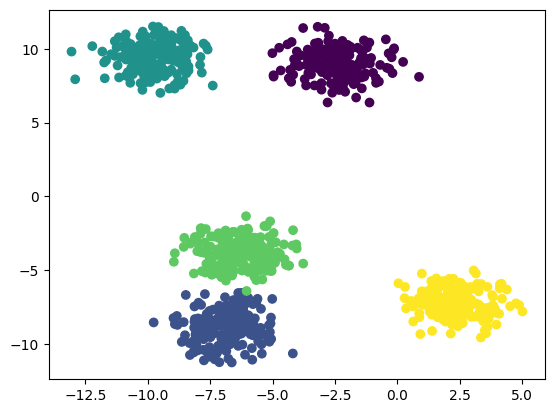

In [5]:
plt.scatter(X[:,0],X[:,1],c=y)

In [6]:
## standardization--feature scaling technique
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

In [9]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [10]:
from sklearn.cluster import KMeans

In [11]:
## Elbow method To select K Value
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)

In [12]:
wcss

[3350.0,
 2338.9406548356746,
 1455.2890657296787,
 581.0214853859925,
 188.57360256402112,
 177.93400265949214,
 171.17314656059446,
 160.31368337041076,
 151.25507424403298,
 147.05121000831303]

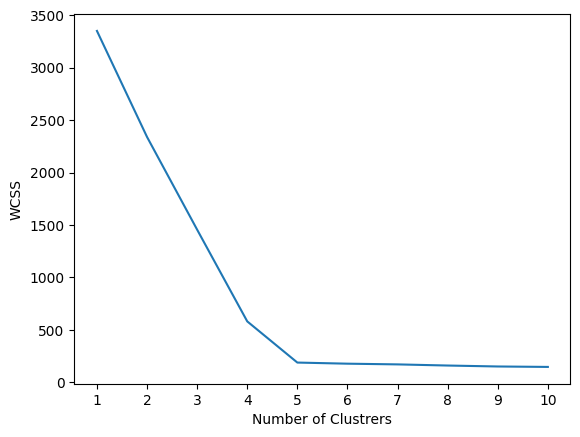

In [13]:
## plot elbow curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Clustrers")
plt.ylabel("WCSS")
plt.show()

In [14]:
kmeans=KMeans(n_clusters=3,init="k-means++")

In [15]:
kmeans.fit_predict(X_train_scaled)

array([0, 2, 2, 0, 0, 0, 1, 2, 0, 1, 1, 2, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 2, 0, 1, 2, 0, 0, 1, 1, 0, 2, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 1, 0, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 2, 2, 1, 0, 1, 0, 1, 0, 1, 2, 2, 0, 0, 1, 2, 2, 0, 2, 0,
       0, 0, 1, 0, 2, 0, 0, 0, 2, 0, 0, 0, 0, 0, 2, 1, 0, 2, 0, 1, 1, 0,
       2, 0, 0, 0, 0, 0, 0, 1, 0, 2, 2, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 2, 1, 0, 2, 0, 1, 0, 0,
       0, 0, 2, 0, 2, 1, 1, 1, 0, 2, 0, 0, 0, 1, 0, 0, 0, 2, 0, 0, 0, 1,
       1, 0, 0, 2, 0, 0, 2, 0, 0, 0, 0, 2, 2, 0, 2, 2, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 0, 1, 2, 2, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 2, 0,
       1, 2, 0, 0, 1, 1, 0, 1, 0, 0, 2, 0, 0, 1, 1, 0, 2, 1, 1, 2, 0, 0,
       0, 0, 1, 1, 2, 1, 1, 0, 2, 0, 2, 0, 0, 1, 0, 2, 0, 2, 0, 1, 1, 2,
       0, 0, 1, 0, 0, 0, 0, 2, 1, 0, 2, 0, 0, 1, 1, 0, 0, 0, 0, 2, 0, 0,
       0, 0, 0, 2, 0, 1, 0, 1, 1, 0, 2, 2, 0, 0, 0,

In [16]:
y_pred=kmeans.predict(X_test_scaled)

In [17]:
y_pred

array([1, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 2, 2, 1, 0, 1, 0, 1, 0, 1, 2,
       2, 2, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 1, 2, 0, 0, 0, 0, 0, 0, 0,
       0, 2, 1, 0, 0, 0, 0, 0, 0, 2, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 2,
       0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 2, 0, 2, 2, 0,
       1, 2, 1, 1, 0, 0, 0, 1, 0, 0, 2, 0, 0, 1, 0, 2, 2, 0, 2, 1, 0, 2,
       0, 0, 2, 1, 0, 2, 0, 0, 1, 0, 0, 2, 0, 0, 2, 2, 2, 1, 1, 0, 0, 0,
       0, 0, 1, 2, 2, 1, 0, 1, 2, 0, 0, 0, 0, 0, 2, 1, 0, 0, 0, 0, 0, 2,
       0, 1, 0, 1, 0, 2, 0, 1, 1, 0, 0, 0, 0, 0, 2, 0, 2, 0, 0, 0, 2, 2,
       1, 0, 1, 1, 0, 0, 0, 0, 2, 1, 0, 0, 2, 1, 0, 2, 0, 2, 0, 0, 1, 0,
       0, 0, 0, 2, 1, 0, 1, 0, 2, 0, 0, 1, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0,
       0, 2, 0, 0, 0, 0, 1, 1, 2, 0, 0, 0, 1, 0, 2, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 2, 0, 2, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 2, 2, 0, 1, 0, 2, 0, 2, 1, 2, 2, 2, 0, 1, 2, 0, 0,
       2, 2, 2, 0, 2, 0, 0, 2, 0, 1, 0, 0, 0, 0, 2,

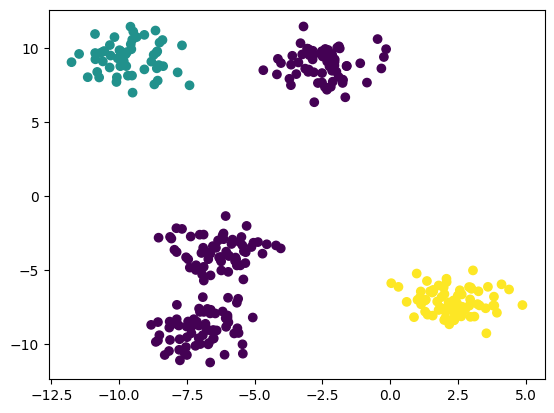

In [18]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)

In [19]:
## Validating the k value
## kneelocator
## Silhoutee scoring

In [20]:
from kneed import KneeLocator

In [21]:
kl=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")

In [22]:
kl.elbow

np.int64(5)

In [23]:
## silhoutte score
from sklearn.metrics import silhouette_score

In [24]:
silhouette_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    score=silhouette_score(X_train_scaled,kmeans.labels_)
    silhouette_coefficients.append(score)

In [25]:
silhouette_coefficients

[np.float64(0.39481916899386926),
 np.float64(0.4827595028411036),
 np.float64(0.6287796329057067),
 np.float64(0.7284947036743357),
 np.float64(0.6227163493471052),
 np.float64(0.5257408149819462),
 np.float64(0.3993154847763202),
 np.float64(0.30539068566807104),
 np.float64(0.4095680655051351)]

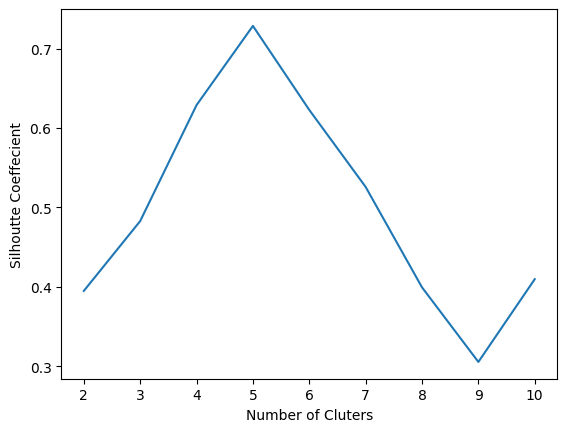

In [26]:
## plotting silhouette score
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of Cluters")
plt.ylabel("Silhoutte Coeffecient")
plt.show()